## Perception + Amenity

In [2]:
import geopandas as gpd
import pandas as pd
import json

# Load GeoParquet file
gdf = gpd.read_parquet(r"D:\IaaC\2ND_YEAR\THESIS\LLM_Based_UrbanABM\Documentation\agent_recording_session_2026-03-29T00-40-26_both.parquet")

# Basic statistics
print(f"Total records: {len(gdf)}")
print(f"Unique agents: {gdf['agent_id'].nunique()}")
print(f"Steps: {gdf['step'].min()} to {gdf['step'].max()}")

Total records: 5000
Unique agents: 15
Steps: 1337 to 1672


Total records: 5000
Unique agents: 15
Steps: 1337 to 1672


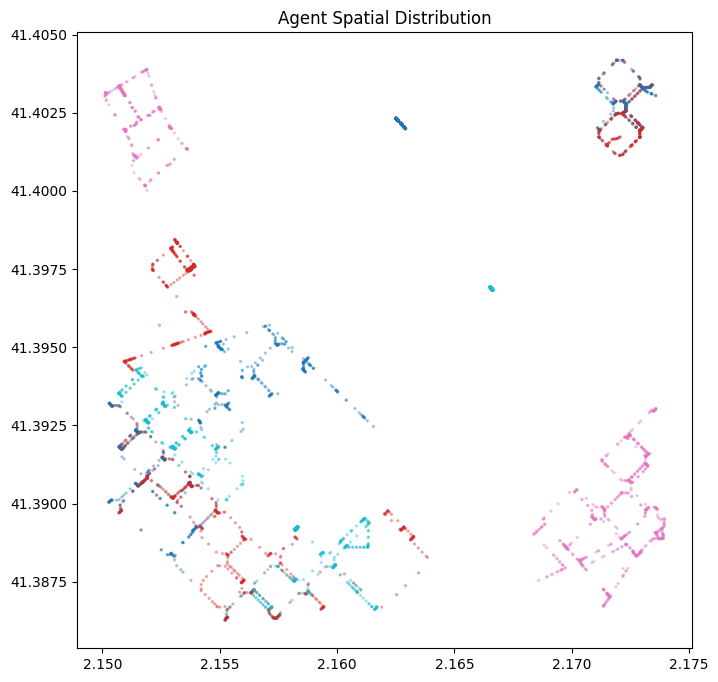

In [6]:
import geopandas as gpd
import pandas as pd
import json

# Load GeoParquet file
gdf = gpd.read_parquet(r"D:\IaaC\2ND_YEAR\THESIS\LLM_Based_UrbanABM\Documentation\agent_recording_session_2026-03-29T00-40-26_both.parquet")

# Basic statistics
print(f"Total records: {len(gdf)}")
print(f"Unique agents: {gdf['agent_id'].nunique()}")
print(f"Steps: {gdf['step'].min()} to {gdf['step'].max()}")

# Parse JSON columns
gdf['needs'] = gdf['needs_json'].apply(json.loads)
gdf['cognition'] = gdf['cognition_state_json'].apply(json.loads)

# Extract needs into separate columns
gdf['hunger'] = gdf['needs'].apply(lambda x: x.get('hunger', 0))
gdf['energy'] = gdf['needs'].apply(lambda x: x.get('energy', 0))
gdf['social'] = gdf['needs'].apply(lambda x: x.get('social', 0))

# Filter by archetype
residents = gdf[gdf['archetype'] == 'resident']
tourists = gdf[gdf['archetype'] == 'tourist']

# Spatial analysis: create trajectory for each agent
trajectories = gdf.dissolve(by='agent_id', as_index=False)

# Visualize agent density
from shapely.geometry import Point
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(ax=ax, markersize=2, alpha=0.3, column='archetype', categorical=True)
plt.title("Agent Spatial Distribution")
plt.show()